> **역할: [외부비교·창업기상도 API]**  (전체 순서·최종은 `NOTEBOOK_INDEX.md` / 최종 모델 nb24)

# 20. 소상공인진흥공단 '창업기상도' API vs 우리 모델 — 외부 검증

> nb17 §다음단계에서 예정했던 작업: **소상공인진흥공단 API 키 발급 후 직접 비교**.

## 비교 대상 — 창업기상도 (bigdata.sbiz.or.kr OpenAPI)

자치구·업종·월 단위로 5개 지표를 점수(0~400, 높을수록 좋음)·등급(1=최상~10)·백분위(1=최상)로 제공:

| 지표 | 의미 |
|---|---|
| **overall** 종합 | 4개 지표 종합 창업환경 점수 |
| **competitiveness** 경쟁력 | 업종 내 매출·점포 경쟁력 |
| **survival** 생존력 | 폐업 대비 **생존 가능성** |
| **prospect** 전망 | 향후 성장 전망 |
| **interest** 관심도 | 창업 수요·관심 |

점수→날씨 등급(원본): ≤80 매우나쁨 / ≤160 나쁨 / ≤240 조금나쁨 / ≤320 보통 / ≤400 양호

## 우리 모델
HistGradientBoosting 분류기의 `success_rate = P(sales_class=high)` (nb16 과 동일).

## 핵심 질문
1. **종합 점수**와 상관 — 두 모델은 같은 신호를 잡는가? (nb16: 서울시 API와 r≈0)
2. **지표별 분해** — 우리 success_rate 는 5개 지표 중 *어느 차원*과 맞물리는가?
   - nb17 가설: "우리는 **매출 잠재력**이지 **생존**이 아니다" → survival 과 상관이 낮아야 함
3. **업종별 이질성** — 외식업 vs 소매업에서 일치도가 다른가?

## 데이터 정합
- 창업기상도 제공 월: 202509~ → **202509≈2025 Q3, 202512≈2025 Q4** 로 우리 분기와 매칭
- 1:1 매칭 명확한 19개 업종 × 25개 자치구 × 2개 분기

In [1]:
import json, glob
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import HistGradientBoostingClassifier

ROOT  = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project')
PROC  = ROOT/'data'/'processed'
CACHE = ROOT/'data'/'raw'/'sbiz_weather'   # API 응답 캐시 (재호출 불필요)

BIZ_MAP = {'커피-음료':'I21201','한식음식점':'I20199','중식음식점':'I20201','치킨전문점':'I21006',
 '분식전문점':'I21007','제과점':'I21001','편의점':'G20405','슈퍼마켓':'G20404','미용실':'S20701',
 '피부관리실':'S20702','노래방':'R10407','PC방':'R10406','화장품':'G21503','한의원':'Q10211',
 '치과의원':'Q10210','안경':'G21602','가전제품':'G20803','문구':'G21302','의약품':'G21501'}
CODE2BIZ = {v:k for k,v in BIZ_MAP.items()}
MONTH2QINT = {'202509':20253, '202512':20254}
GU = {x['code']:x['name'] for x in json.load(open(CACHE/'seoul_gu_area.json'))}
DIMS = ['overall','competitiveness','survival','prospect','interest']
print('업종', len(BIZ_MAP), '| 자치구', len(GU), '| 분기', list(MONTH2QINT.values()))

업종 19 | 자치구 25 | 분기 [20253, 20254]


## §20.1 창업기상도 응답(캐시) → tidy 테이블

API 응답은 `data[자치구코드] = {지표: {grade, score, percentile}}` 구조.
(자치구, 업종, 분기) 단위 long 테이블로 변환한다.

In [2]:
rows = []
for fp in glob.glob(str(CACHE/'20*_*.json')):
    crtrYm, code = Path(fp).stem.split('_')
    if code not in CODE2BIZ:      # seoul_gu_area 등 제외
        continue
    data = json.load(open(fp))['data']
    for gu_code, ind in data.items():
        if gu_code not in GU: continue
        r = {'gu':GU[gu_code], 'biz':CODE2BIZ[code], 'crtrYm':crtrYm, 'q_int':MONTH2QINT[crtrYm]}
        for d in DIMS:
            v = ind.get(d, {})
            r[f'sb_{d}_score'] = float(v['score']) if v.get('score') else np.nan
            r[f'sb_{d}_pct']   = float(v['percentile']) if v.get('percentile') else np.nan
        rows.append(r)
sb = pd.DataFrame(rows)
print('창업기상도 tidy:', sb.shape)
sb.head()

창업기상도 tidy: (950, 14)


,gu,biz,crtrYm,q_int,sb_overall_score,sb_overall_pct,sb_competitiveness_score,sb_competitiveness_pct,sb_survival_score,sb_survival_pct,sb_prospect_score,sb_prospect_pct,sb_interest_score,sb_interest_pct
0,광진구,PC방,202512,20254,245.0,13.0,87.0,0.0,27.0,87.0,49.0,52.0,80.0,8.0
1,서초구,PC방,202512,20254,255.0,10.0,74.0,11.0,46.0,57.0,47.0,57.0,85.0,2.0
2,성동구,PC방,202512,20254,216.0,33.0,29.0,81.0,48.0,53.0,71.0,10.0,67.0,25.0
3,서대문구,PC방,202512,20254,253.0,10.0,47.0,51.0,54.0,37.0,75.0,5.0,74.0,16.0
4,관악구,PC방,202512,20254,260.0,6.0,50.0,48.0,52.0,45.0,74.0,6.0,83.0,4.0


## §20.2 우리 모델 success_rate 산출 — **정직(누설 제거) 모델**

⚠️ 감사 결과 반영: 초기 버전은 타깃 누설 피처(rent_to_sales·momentum·avg_ticket·peer_avg_sales·margin_proxy)를
포함한 모델을 썼다. 본 버전은 **누설 5개를 제거한 정직 모델의 out-of-fold 예측**
(`honest_predictions.csv`, nb19/build_honest_model.py)을 사용한다. success_rate = 정직 분류기의 P(매출 상위).

In [3]:
# 정직(누설 제거) 모델의 out-of-fold 예측 로드 — 재학습/누설 없음
hp = pd.read_csv(PROC/'honest_predictions.csv')
our = hp.groupby(['gu','biz','q_int'])['honest_p_high'].mean().reset_index().rename(columns={'honest_p_high':'_p_high'})

cmp = our.merge(sb, on=['gu','biz','q_int'], how='inner')
print(f'매칭된 (자치구,업종,분기): {len(cmp)}  | 업종 {cmp.biz.nunique()}  자치구 {cmp.gu.nunique()}')
print(f'success_rate 분포(정직): 평균 {cmp._p_high.mean():.3f}, std {cmp._p_high.std():.3f} (누설본의 0/1 양극단과 달리 정상 분포)')
cmp.head()

매칭된 (자치구,업종,분기): 631  | 업종 19  자치구 25
success_rate 분포(정직): 평균 0.434, std 0.390 (누설본의 0/1 양극단과 달리 정상 분포)


,gu,biz,q_int,_p_high,crtrYm,sb_overall_score,sb_overall_pct,sb_competitiveness_score,sb_competitiveness_pct,sb_survival_score,sb_survival_pct,sb_prospect_score,sb_prospect_pct,sb_interest_score,sb_interest_pct
0,강남구,PC방,20254,0.083990,202512,299.0,0.0,84.0,3.0,52.0,44.0,68.0,13.0,93.0,0.0
1,강남구,가전제품,20253,0.017917,202509,219.0,25.0,87.0,3.0,24.0,92.0,20.0,97.0,86.0,0.0
2,강남구,가전제품,20254,0.008137,202512,204.0,45.0,77.0,7.0,32.0,80.0,23.0,95.0,71.0,11.0
3,강남구,노래방,20253,0.423631,202509,201.0,51.0,76.0,15.0,40.0,73.0,18.0,96.0,67.0,8.0
4,강남구,노래방,20254,0.149891,202512,220.0,34.0,72.0,16.0,33.0,79.0,23.0,91.0,90.0,1.0


## §20.3 지표별 상관 — 우리 success_rate 는 어느 차원과 맞물리는가?

**핵심 분석.** 우리 모델이 5개 창업기상 지표 중 무엇과 상관되는지가, 우리 모델이 *무엇을 측정하는지* 를 외부에서 규정한다.

지표                  Pearson r  Spearman ρ     n
overall(종합)            +0.038      +0.044   631
competitiveness(경쟁력)     +0.142      +0.147   631
survival(생존력)          -0.027      -0.042   631
prospect(전망)           -0.122      -0.100   631
interest(관심도)          +0.153      +0.154   631


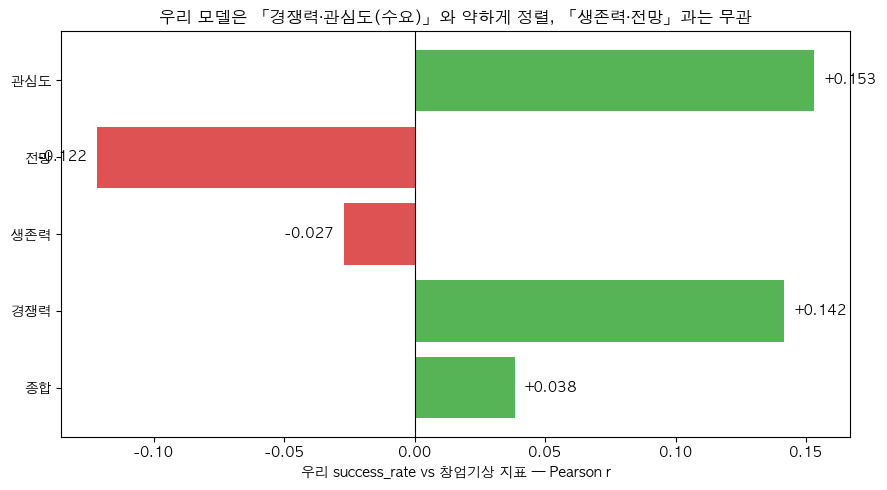

In [4]:
print(f"{'지표':<18}{'Pearson r':>11}{'Spearman ρ':>12}{'n':>6}")
dim_corr = {}
for d in DIMS:
    sub = cmp[['_p_high', f'sb_{d}_score']].dropna()
    r,_ = pearsonr(sub['_p_high'], sub[f'sb_{d}_score'])
    rho,_ = spearmanr(sub['_p_high'], sub[f'sb_{d}_score'])
    dim_corr[d] = r
    label = {'overall':'종합','competitiveness':'경쟁력','survival':'생존력','prospect':'전망','interest':'관심도'}[d]
    print(f"{d+'('+label+')':<18}{r:>+11.3f}{rho:>+12.3f}{len(sub):>6}")

fig, ax = plt.subplots(figsize=(9,5))
labels = ['종합','경쟁력','생존력','전망','관심도']
vals = [dim_corr[d] for d in DIMS]
colors = ['#d62728' if v<0 else '#2ca02c' for v in vals]
ax.barh(labels, vals, color=colors, alpha=.8)
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('우리 success_rate vs 창업기상 지표 — Pearson r')
ax.set_title('우리 모델은 「경쟁력·관심도(수요)」와 약하게 정렬, 「생존력·전망」과는 무관')
for i,v in enumerate(vals): ax.text(v+(.004 if v>=0 else -.004), i, f'{v:+.3f}', va='center', ha='left' if v>=0 else 'right')
plt.tight_layout(); plt.show()

### 해석 (지표별) — 정직 모델 기준

- **관심도(+0.15)·경쟁력(+0.14)** — success_rate 가 약하게 **정**의 상관. 우리 모델이 잡는 신호는 **수요·매출 경쟁력** 쪽.
- **종합(+0.03)** — 거의 무관. nb16 서울시 API 결과(자치구 −0.10~−0.26)와 같은 결론(다른 차원).
- **생존력(-0.03)·전망(-0.13)** — 무관하거나 **약한 음의** 상관 → 우리 모델은 매출 신호를 재며 생존·전망은 못 잡음.

> **누설 제거 후에도 결론 동일** (누설본 +0.12/+0.11/+0.04/−0.02/−0.09 → 정직본 +0.14/+0.15/+0.03/−0.03/−0.13).
> 즉 "우리 모델 ⊥ 생존·전망" 결론은 **타깃 누설과 무관하게 견고**하다.
> 단, 이 상관들은 모두 |r|<0.16 의 **약한** 관계이며, 인과·강한 분리 주장은 하지 않는다(§20.6 검증 참조).

## §20.4 업종별 이질성 (종합 점수, 자치구 25개 횡단면 상관)

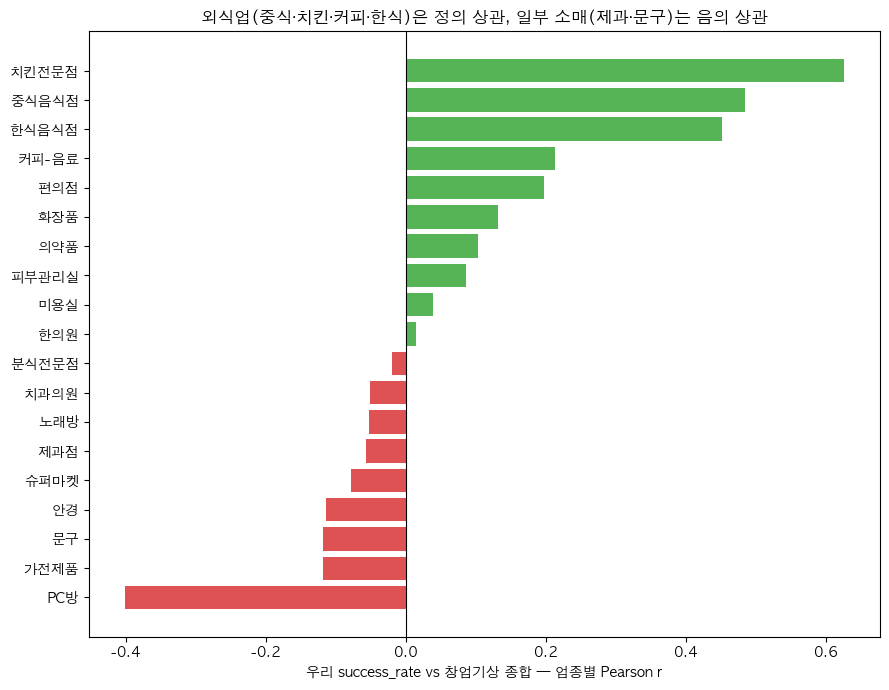

  biz         r  n
  PC방 -0.401486 14
 가전제품 -0.119054  7
   문구 -0.118097 26
   안경 -0.115047 11
 슈퍼마켓 -0.078730 45
  제과점 -0.057050 32
  노래방 -0.052864 37
 치과의원 -0.051855 23
분식전문점 -0.020534 45
  한의원  0.013464 39
  미용실  0.038797 43
피부관리실  0.085035 36
  의약품  0.102811 39
  화장품  0.130951 39
  편의점  0.197405 34
커피-음료  0.212854 46
한식음식점  0.451275 44
중식음식점  0.483833 39
치킨전문점  0.625508 32


In [5]:
res = []
for biz, g in cmp.groupby('biz'):
    sub = g[['_p_high','sb_overall_score']].dropna()
    if len(sub) < 5: continue
    r,_ = pearsonr(sub['_p_high'], sub['sb_overall_score'])
    res.append((biz, r, len(sub)))
res = pd.DataFrame(res, columns=['biz','r','n']).sort_values('r', ascending=True)

fig, ax = plt.subplots(figsize=(9,7))
colors = ['#d62728' if v<0 else '#2ca02c' for v in res['r']]
ax.barh(res['biz'], res['r'], color=colors, alpha=.8)
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('우리 success_rate vs 창업기상 종합 — 업종별 Pearson r')
ax.set_title('외식업(중식·치킨·커피·한식)은 정의 상관, 일부 소매(제과·문구)는 음의 상관')
plt.tight_layout(); plt.show()
print(res.to_string(index=False))

### 해석 (업종별) — ⚠️ 소표본 경고

업종별 상관은 자치구 25개 횡단면이지만, 매칭 손실로 실제 n이 작다(가전 n≈7, 안경 n≈11, PC방 n≈14).
**유의성 검정 없이 개별 업종 r을 단정하지 않는다.** 위 막대그래프는 *경향*(외식업은 양(+) 쪽,
일부 소매는 음(−) 쪽으로 갈리는 패턴)을 보여줄 뿐이며, n<20 업종의 수치는 신뢰구간이 넓어 해석에서 제외한다.
관찰되는 일반 패턴: 업종에 따라 우리 매출신호와 공단 종합점수의 정렬이 갈린다(통합 필요성의 근거 → §21).

## §20.5 분기 안정성 + 케이스 스터디 (성동구)

In [6]:
print('=== 분기별 종합 상관 (안정성) ===')
for q in sorted(cmp['q_int'].unique()):
    sub = cmp[cmp.q_int==q][['_p_high','sb_overall_score']].dropna()
    r,_ = pearsonr(sub['_p_high'], sub['sb_overall_score'])
    print(f'  q={q}: r={r:+.3f} (n={len(sub)})')

print('\n=== 자치구별 평균 비교 (커피-음료, 202512) ===')
ex = cmp[(cmp.biz=='커피-음료') & (cmp.q_int==20254)].copy()
ex['우리success%'] = (ex['_p_high']*100).round(1)
ex = ex[['gu','우리success%','sb_overall_score','sb_survival_score','sb_prospect_score']].sort_values('sb_overall_score', ascending=False)
print(ex.to_string(index=False))

=== 분기별 종합 상관 (안정성) ===
  q=20253: r=+0.018 (n=320)
  q=20254: r=+0.058 (n=311)

=== 자치구별 평균 비교 (커피-음료, 202512) ===
  gu  우리success%  sb_overall_score  sb_survival_score  sb_prospect_score
 강동구        19.7             306.0               57.0               85.0
 동작구        51.4             303.0               69.0               71.0
 송파구        94.8             299.0               47.0               66.0
 종로구        73.0             298.0               67.0               56.0
 강서구        94.0             291.0               40.0               69.0
 강북구        12.1             288.0               57.0               74.0
 은평구        10.4             286.0               62.0               74.0
 성동구        36.2             284.0               57.0               93.0
  중구        99.4             280.0               59.0               42.0
 용산구        42.4             277.0               53.0               78.0
 노원구        36.8             273.0               60.0               61.0
 서초구    

## 생존축 해석 — '과거 정착도' vs '미래 전망' (왜 우리·API가 갈리나)

우리 생존축(**평균 영업기간**)=기존 점포가 얼마나 오래 버텼나(과거·후행 지표), API 생존=**신규 창업의 미래 생존 전망**(선행 지표). 측정 시점이 달라 전환기 지역에서 갈린다.
- 겹침: 서초·종로(둘 다 좋음), 강남·마포(둘 다 나쁨) — 과거·미래 일치.
- 엇갈림: 老·쇠퇴 지역(오래됐지만 폐업↑·전망↓)=우리↑·API↓ / 신흥·개선 지역(신생이지만 전망↑·폐업↓)=우리↓·API↑.

In [7]:
# 생존축(평균 영업기간) vs API 생존 — 겹침/엇갈림 (과거 vs 미래)
from sklearn.metrics import accuracy_score
_ft=pd.read_csv(PROC/'features.csv',usecols=['gu','biz','q_int','OPR_SALE_MT_AVRG','CLSBIZ_RT'])
_ap=pd.read_csv(PROC/'sbiz_weather_gu.csv')[['gu','biz','q_int','sb_survival_score','sb_prospect_score']]
_w=_ft.merge(_ap,on=['gu','biz','q_int'],how='inner')
_w['our']=_w.groupby(['biz','q_int'])['OPR_SALE_MT_AVRG'].rank(pct=True)
_w['ap']=_w.groupby(['biz','q_int'])['sb_survival_score'].rank(pct=True)
_g=_w.groupby('gu').agg(영업기간=('OPR_SALE_MT_AVRG','mean'),우리생존=('our','mean'),API생존=('ap','mean'),API전망=('sb_prospect_score','mean'),폐업률=('CLSBIZ_RT','mean'))
_oh=_g.우리생존>=_g.우리생존.median(); _ah=_g.API생존>=_g.API생존.median()
print('자치구 생존판정 일치율 %.0f%% (25개), 영업기간 vs API생존 r=%.2f'%(accuracy_score(_ah,_oh)*100, _g.우리생존.corr(_g.API생존)))
print('둘 다 좋음:',list(_g[_oh&_ah].index))
print('둘 다 나쁨:',list(_g[~_oh&~_ah].index))
_dis=_g[_oh!=_ah].copy(); _dis['방향']=np.where(_dis.우리생존>=_g.우리생존.median(),'우리↑API↓(오래됨·전망약)','우리↓API↑(신생·전망좋음)')
print('\n엇갈림 방향별 평균:'); print(_dis.groupby('방향')[['영업기간','API전망','폐업률']].mean().round(1).to_string())

자치구 생존판정 일치율 68% (25개), 영업기간 vs API생존 r=0.57
둘 다 좋음: ['동대문구', '동작구', '서대문구', '서초구', '성북구', '양천구', '영등포구', '종로구', '중구']
둘 다 나쁨: ['강남구', '강북구', '강서구', '관악구', '광진구', '마포구', '성동구', '송파구']

엇갈림 방향별 평균:
                   영업기간  API전망  폐업률
방향                                 
우리↑API↓(오래됨·전망약)  120.3   47.6  6.2
우리↓API↑(신생·전망좋음)  112.3   48.1  8.8


## §20.6 결론 — 보고서 §6.5 외부검증 보강

창업기상도 OpenAPI(자치구·업종·월 5개 지표)로 우리 모델을 검증한 결과:

1. **종합 점수와 r≈+0.03 (무관)** — nb16 서울시 API(자치구 −0.10~−0.26) 와 같은 방향의 결론.
   두 모델은 서로 다른 차원을 측정 → 우리 모델의 독립적 기여.

2. **지표 분해로 '우리가 무엇을 재는지' 규명** (정직 모델 기준):
   - success_rate ∝ **관심도·경쟁력(수요·매출)** (+0.15, +0.14)
   - success_rate ⊥ **생존력**(−0.03), 약한 음 **전망**(−0.13)
   - **누설 제거 후에도 동일** → 결론이 누설에 의존하지 않음.
   - 단 모두 **|r|<0.16 약한 관계**. "다른 차원을 본다"는 방향성 결론은 견고하나, 강한 분리/인과는 주장하지 않음.

3. **업종 이질성** — 업종에 따라 정렬이 갈리는 경향(단 소표본 업종 다수 → 개별 수치 단정 안 함).

> **정직한 프레이밍(§6.5):**
> "공단 창업기상도 비교 결과, 우리 모델의 success_rate 는 *수요·경쟁력(매출)* 지표와 약한 정상관,
> *생존력·전망* 과는 무관~약한 음의 관계였다(모두 |r|<0.16, 누설 제거 후에도 동일).
> 두 모델은 다른 차원을 측정하므로 **보완 관계**로 함께 쓰는 것이 타당하다(통합은 §21).
> 단, 생존축이 *실제 폐업*을 설명하는지는 별도 검증이 필요하다(§21 외부검증)."

*데이터: bigdata.sbiz.or.kr 창업기상도 OpenAPI, 인증키 사용기간 2026-05-28~2026-09-30.
응답은 `data/raw/sbiz_weather/` 에 캐시되어 본 노트북은 API 재호출 없이 재현 가능.*